In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

In [ ]:
# Importando os arquivos
df_companies = pd.read_csv('/datasets/project_sql_result_01.csv')
df_neighborhoods = pd.read_csv('/datasets/project_sql_result_04.csv')

# Estudo inicial dos dados
print(df_companies.info())
print('-' * 30)
print(df_neighborhoods.info())

# Verificação visual das primeiras linhas
df_companies.head()
df_neighborhoods.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


In [ ]:
# Ordenando pelos destinos mais frequentes e pegando os 10 primeiros
top_10_neighborhoods = df_neighborhoods.sort_values(by='average_trips', ascending=False).head(10)

print("Top 10 Bairros por Destino:")
print(top_10_neighborhoods)

Top 10 Bairros por Destino:
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


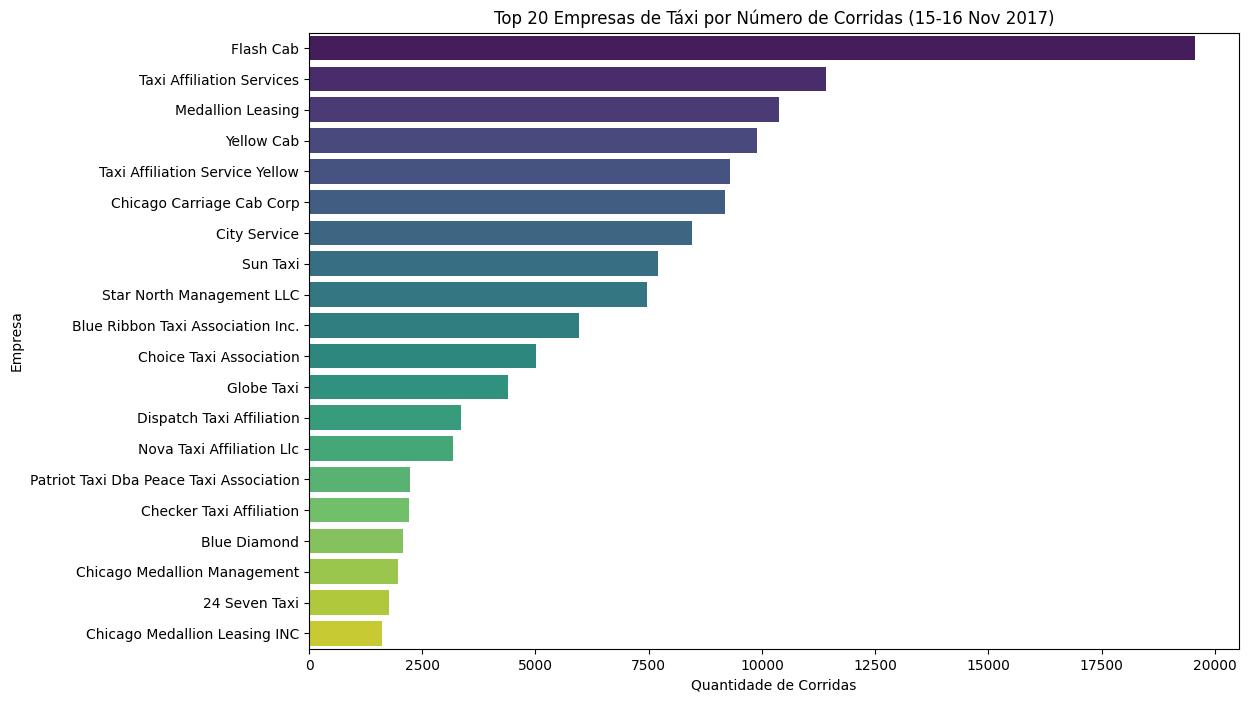

In [ ]:
# Gráfico Empresas de Táxi x Número de Corridas
plt.figure(figsize=(12, 8))
sns.barplot(data=df_companies.sort_values(by='trips_amount', ascending=False).head(20),
            x='trips_amount', y='company_name', palette='viridis')
plt.title('Top 20 Empresas de Táxi por Número de Corridas (15-16 Nov 2017)')
plt.xlabel('Quantidade de Corridas')
plt.ylabel('Empresa')
plt.show()

O mercado de Chicago apresenta uma concentração muito alta. A Flash Cab e a Taxi Affiliation Services dominam o volume de viagens. Para a Zuber, isso indica que o desafio não é apenas tecnológico, mas de escala de frota para competir com esses gigantes.

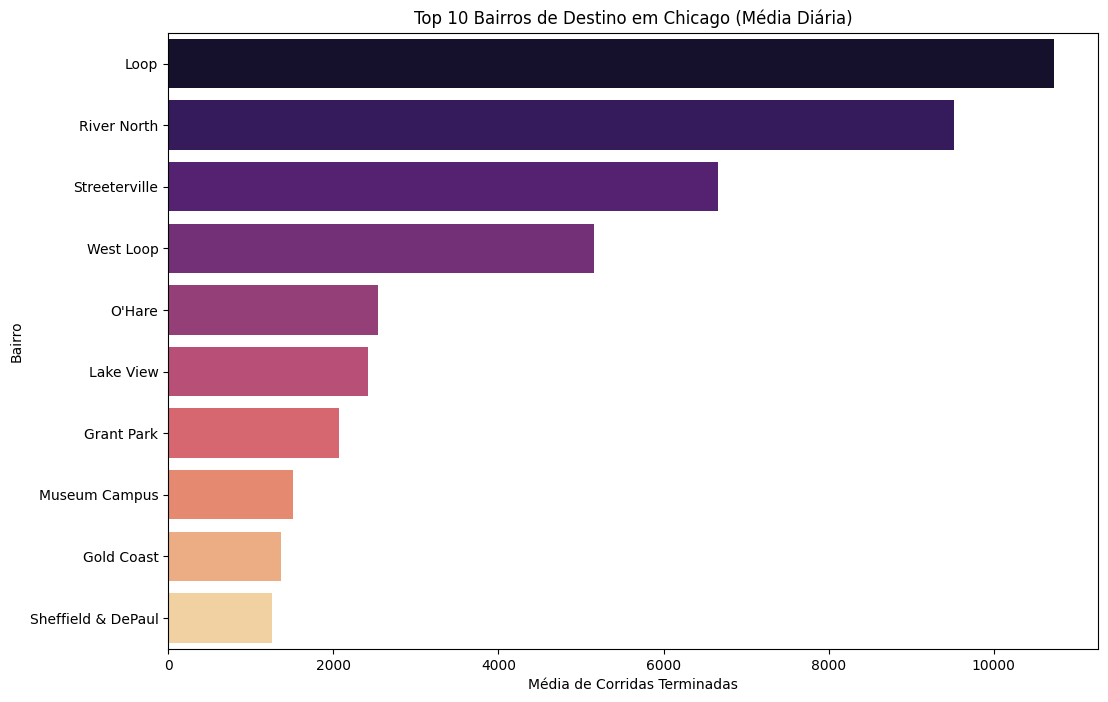

In [ ]:
# Top 10 bairros por destinos (média de viagens)
plt.figure(figsize=(12, 8))
sns.barplot(data=top_10_neighborhoods, x='average_trips', y='dropoff_location_name', palette='magma')
plt.title('Top 10 Bairros de Destino em Chicago (Média Diária)')
plt.xlabel('Média de Corridas Terminadas')
plt.ylabel('Bairro')
plt.show()

Há uma concentração extrema de viagens em poucos bairros específicos. O volume de destinos no primeiro bairro (Loop) é significativamente maior que a soma de vários bairros das posições inferiores, sugerindo que a infraestrutura de transporte de Chicago possui "hubs" ou pontos focais de convergência muito claros. Loop, River North e Streeterville são destinos amplamente mais cobiçados na cidade do que os outros, podem fazer parte de uma rota turística e área central da cidade.

In [ ]:
# Carregando os dados
df_hyp = pd.read_csv('/datasets/project_sql_result_07.csv')

# Separando as amostras
# Grupo A: Sábados com tempo 'Bad' (chuva/tempestade)
bad_weather_trips = df_hyp[df_hyp['weather_conditions'] == 'Bad']['duration_seconds']

# Grupo B: Sábados com tempo 'Good'
good_weather_trips = df_hyp[df_hyp['weather_conditions'] == 'Good']['duration_seconds']

In [ ]:
# Definindo o nível de significância (alfa)
alpha = 0.05

# Realizando o teste de hipótese
# Usamos o teste t de Student para duas amostras independentes
results = st.ttest_ind(bad_weather_trips, good_weather_trips, equal_var= bad_weather_trips.var() == good_weather_trips.var())

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print("Rejeitamos a hipótese nula")
else:
    print("Não podemos rejeitar a hipótese nula")

p-value: 6.738994326108734e-12
Rejeitamos a hipótese nula


    Hipótese Nula (H_0): A duração média das viagens do Loop para o Aeroporto O'Hare é a mesma em sábados chuvosos e em sábados de tempo bom.

A hipótese nula sempre assume a igualdade ou a ausência de efeito.

    Hipótese Alternativa (H_1): A duração média das viagens do Loop para o Aeroporto O'Hare muda (é diferente) nos sábados chuvosos em comparação aos de tempo bom.

Esta é a hipótese que queremos testar; ela assume que o fator externo (clima) provoca uma alteração significativa no tempo de viagem.

Teste Utilizado: Teste t de Student para amostras independentes.
Porque este teste foi o escolhido:
1. Estamos comparando as médias de duas populações distintas (viagens na chuva vs. viagens no sol);
2. As amostras são independentes, pois uma corrida realizada no sol não influencia a duração de uma corrida realizada na chuva;
3. A variável dependente (duration_seconds) é contínua, o que é um requisito para este teste.

Em relação ao Nível de Significância, escolhi 5% porque ele oferece um equilíbrio seguro entre o risco de Falso Positivo (dizer que o clima afeta quando não afeta) e Falso Negativo.

Conclusão Final
Os testes estatísticos indicam que o clima tem um impacto significativo na duração das viagens entre o Loop e o aeroporto. Para a Zuber, isso pode significar que o sistema de precificação dinâmica deve considerar não apenas a demanda de passageiros, mas também as previsões meteorológicas em tempo real, já que o tempo de ocupação do motorista aumenta em dias 'Bad', reduzindo a oferta de veículos na rua.